# To Do:

- Implement the two site gates 
- Convert to MPO or rewrite everything in terms of MPO
- Study the time evolution

In [1]:
##################
# Library imports #
###################

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed, dump

from tenpy.networks.mps import MPS
from tenpy.networks.mpo import MPO
from tenpy.models.model import CouplingMPOModel
from tenpy.networks import site
from tenpy.algorithms import tdvp

In [2]:
def visualise_matrix(U, t, cmap='Greys', figsize=(6,6)):
    # Construct a 16 x 16 Hamiltonian matrix for vizualization purposes
    plt.figure(figsize=figsize)
    plt.imshow(U.real, cmap=cmap) 
    plt.title(f'Time step {t}')
    plt.xlabel('Column')
    plt.ylabel('Row')
    plt.colorbar()
    plt.show()

def random_unitary(gates, circuit, L, T):

    U_t = np.zeros(T, dtype=object)

    for t in range(T):

        U = np.eye(1) # Start with identity
        
        for i in range(L):

            if circuit[t, i] == 'I':
                U = np.kron(U, gates['I'])
            elif circuit[t, i] == 'X':
                U = np.kron(U, gates['X'])
            elif circuit[t, i] == 'Z':
                U = np.kron(U, gates['Z'])
        
        U_t[t] = U

    return U_t

In [32]:
def plot_quantum_circuit(circuit, L, T):

    fig, ax = plt.subplots(figsize=(max(12, T * 1.5), L * 1.5))
    
    # Draw gates first
    for t in range(T):
        for i in range(L):
            gate_label = circuit[t, i]
            x_pos = t + 0.5
            y_pos = L - 1 - i
            
            if gate_label == 'X':
                # Blue circle for X gate
                circle = plt.Circle((x_pos, y_pos), 0.25, fill=True, facecolor='blue', edgecolor='black', linewidth=2, zorder=3)
                ax.add_patch(circle)
            
            elif gate_label == 'Z':
                # Purple circle for Z gate
                circle = plt.Circle((x_pos, y_pos), 0.25, fill=True, facecolor='purple', edgecolor='black', linewidth=2, zorder=3)
                ax.add_patch(circle)
    
    # Draw qubit wires (horizontal lines with gaps for gates)
    for i in range(L):
        y_pos = L - 1 - i
        # Draw line segments that skip over the gate positions
        for t in range(T):
            x_start = t
            x_end = t + 1
            ax.plot([x_start, x_end], [y_pos, y_pos], '-', linewidth=2, color='black', zorder=1)
        
    
    # Set limits and labels
    ax.set_aspect('equal')
    ax.set_xticks([t + 0.5 for t in range(T)])  # Position ticks at gate locations
    ax.set_xticklabels([f'{t}' for t in range(T)], fontsize=T)
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xlabel('Time Step', fontsize=T)
    ax.grid(False)  # Remove grid lines
    
    # Remove the outer box 
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    plt.tight_layout()
    plt.show()


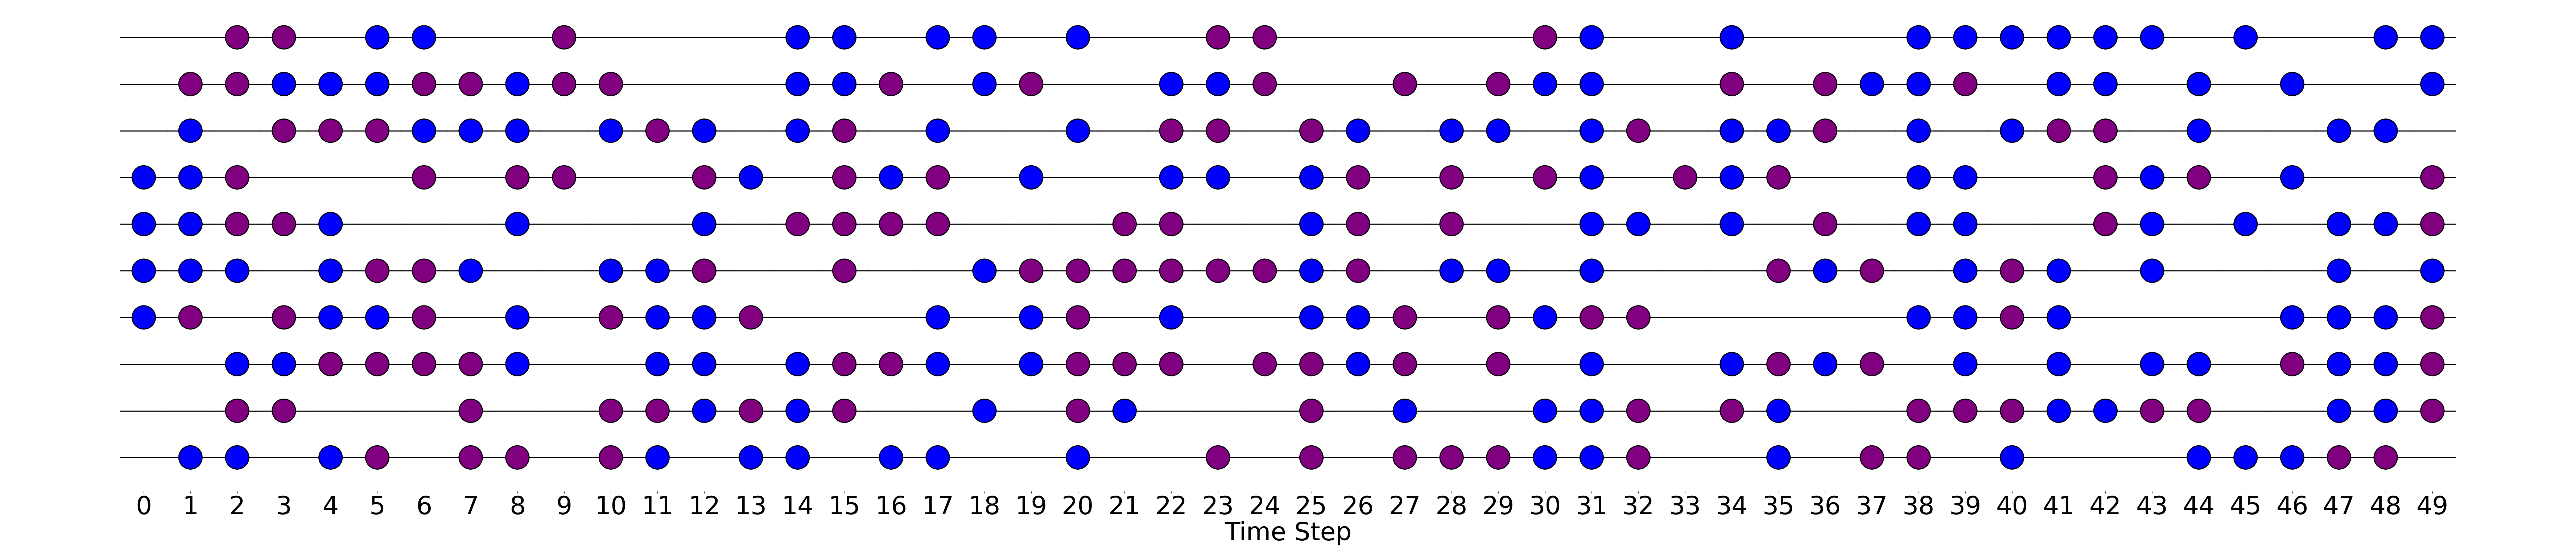

In [38]:
I = np.eye(2)

X = np.array([[0, 1],
              [1, 0]])

Z = np.array([[1, 0],
              [0, -1]])

gates = {'I': I, 'X': X, 'Z': Z} 

L = 10
T = 50

px = 0.3  # Probability of applying X gate
pz = 0.3  # Probability of applying Z gate


circuit = np.random.choice(['I', 'X', 'Z'], size=(T, L), p=[1 - px - pz, px, pz])

U_t = random_unitary(gates, circuit, L, T)

plot_quantum_circuit(circuit, L, T)